# Predictive Maintenance — Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned AI4I 2020 Predictive Maintenance Dataset.

## Objectives

- Understand the distribution of machine operating conditions
- Analyze the distribution of machine failures
- Compare normal and failed machine observations
- Investigate relationships between sensor variables
- Identify potentially important features for machine failure prediction
- Generate initial findings to guide feature engineering and model development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/processed/cleaned_data.csv")
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [4]:
print("Dataset shape:", data.shape)

Dataset shape: (10000, 7)


In [5]:
print(data.dtypes)

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object


In [6]:
print(data.isnull().sum().sum())

0


In [7]:
data.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [9]:
failure_counts = data["Machine failure"].value_counts()

print(failure_counts)

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [10]:
failure_percentages = data["Machine failure"].value_counts(normalize=True) * 100

print(failure_percentages)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


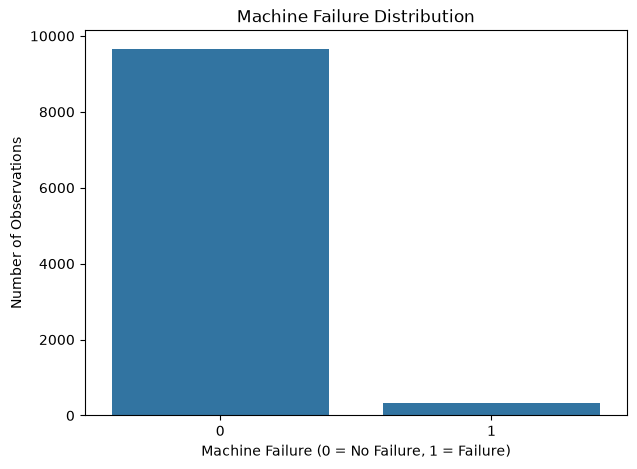

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Observations")

plt.show()

### Finding: Class Distribution

The dataset contains 9,661 normal observations and 339 machine-failure observations. Therefore, approximately 96.61% of observations represent normal operation while only 3.39% represent failure. This significant class imbalance means that accuracy alone may not be sufficient for evaluating the machine failure prediction model.

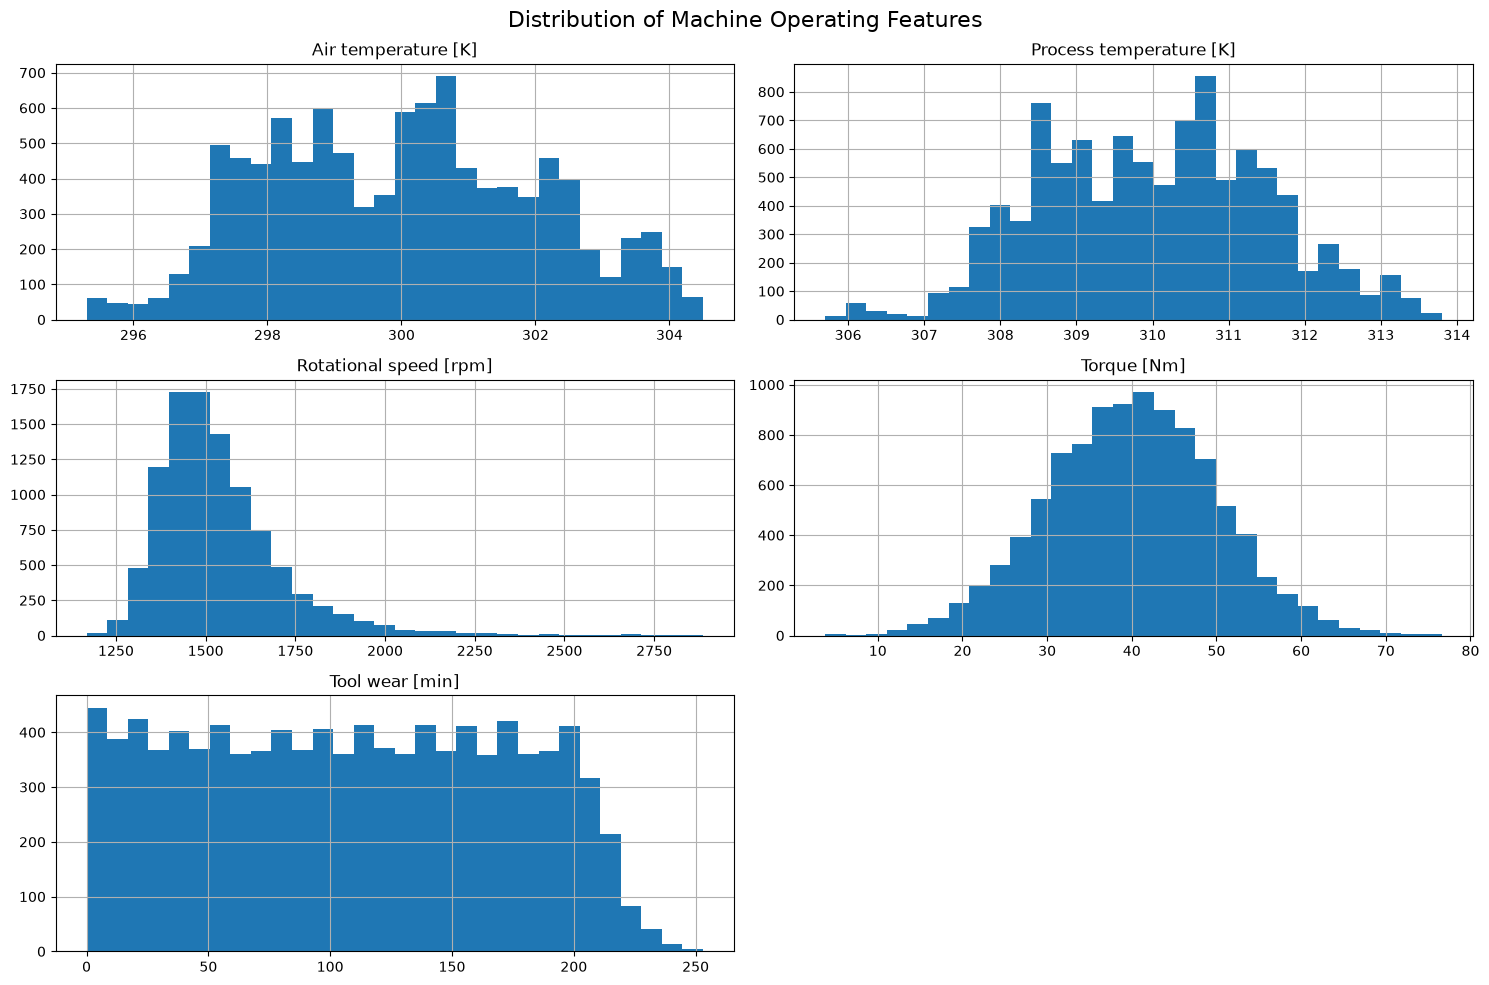

In [12]:
data[numerical_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Machine Operating Features", fontsize=16)

plt.tight_layout()
plt.show()

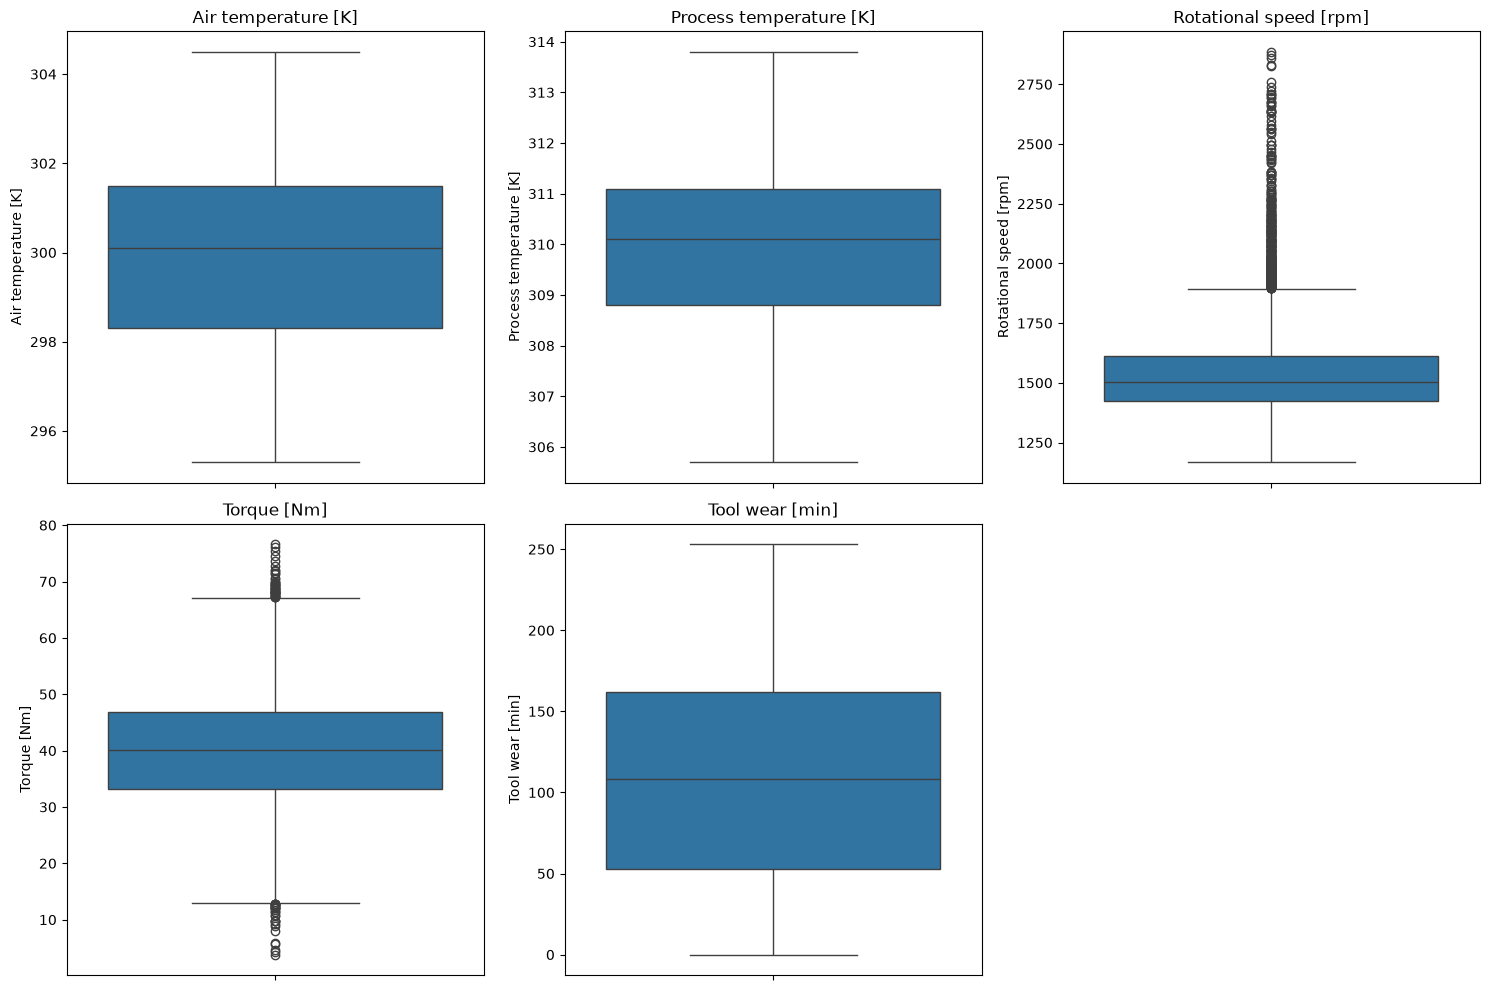

In [45]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=data, y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

In [14]:
failure_means = data.groupby("Machine failure")[numerical_features].mean()

failure_means

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


### Finding: Normal vs Failure Operating Conditions

The mean operating conditions show noticeable differences between normal and failure observations.

- Average torque is higher for failure observations (50.17 Nm) than for normal observations (39.63 Nm), a difference of approximately 10.54 Nm.
- Average tool wear is higher for failure observations (143.78 min) than for normal observations (106.69 min), a difference of approximately 37.09 min.
- Average rotational speed is lower for failure observations (1496.49 rpm) than for normal observations (1540.26 rpm), a difference of approximately 43.77 rpm.
- Air temperature is approximately 0.91 K higher in failure observations, while process temperature is approximately 0.29 K higher.

These differences suggest that torque, tool wear, and rotational speed may contain useful information for predicting machine failure. However, mean differences alone do not establish causation or determine feature importance. Further analysis using distributions, failure rates, correlations, and machine learning models is required.

In [46]:
normal_means = data[data["Machine failure"] == 0][numerical_features].mean()

failure_means_only = data[data["Machine failure"] == 1][numerical_features].mean()

comparison = pd.DataFrame({
    "Normal Mean": normal_means,
    "Failure Mean": failure_means_only
})

comparison["Difference"] = (
    comparison["Failure Mean"] - comparison["Normal Mean"]
)

comparison

,Normal Mean,Failure Mean,Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


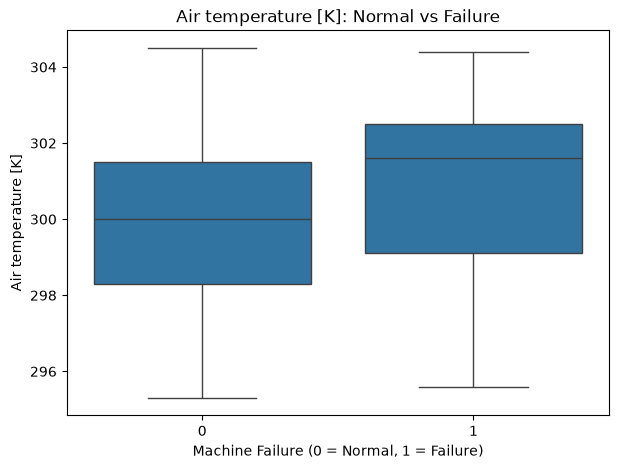

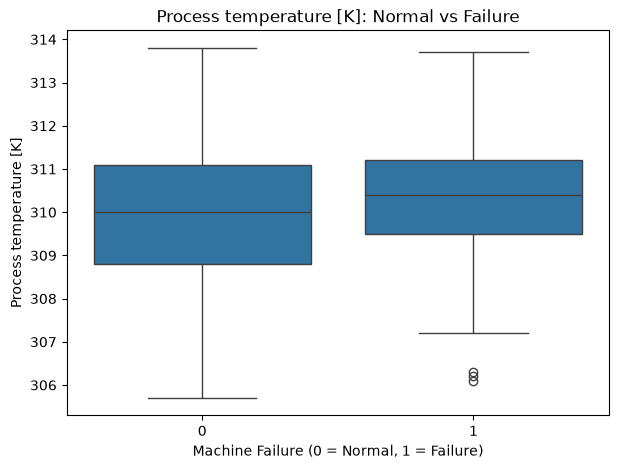

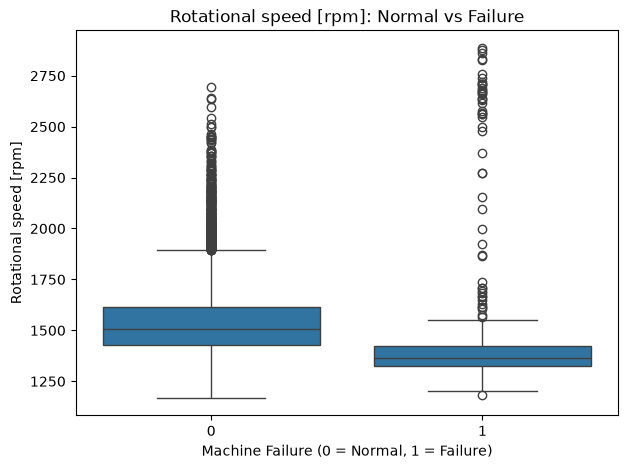

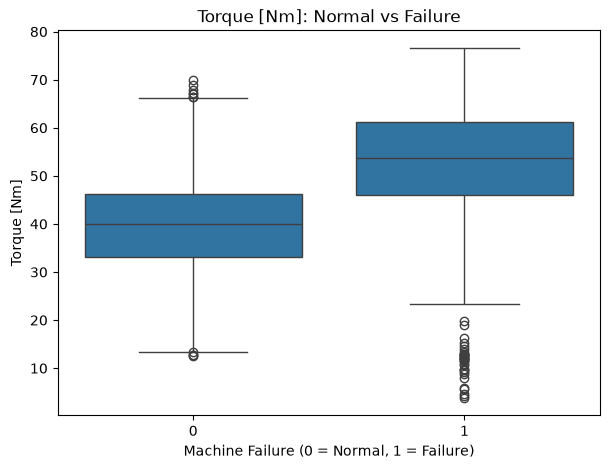

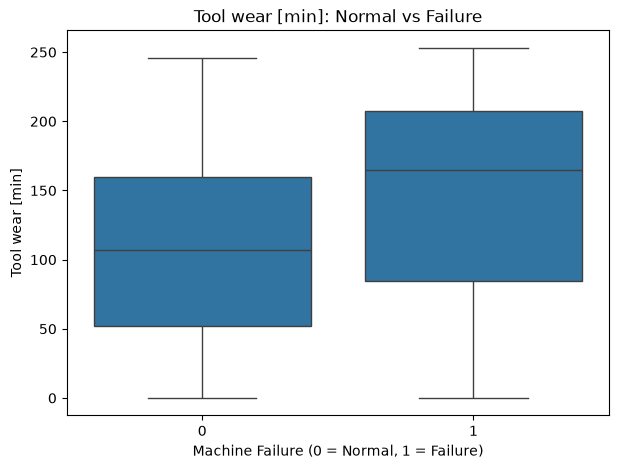

In [16]:
for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=data,
        x="Machine failure",
        y=feature
    )

    plt.title(f"{feature}: Normal vs Failure")
    plt.xlabel("Machine Failure (0 = Normal, 1 = Failure)")
    plt.ylabel(feature)

    plt.show()

### Finding: Normal vs Failure Distributions

The box-plot analysis reveals noticeable differences between normal and failure observations.

- **Torque:** Failure observations show a clear shift toward higher torque values compared with normal observations, suggesting that torque may be an important predictor of machine failure.
- **Tool wear:** Failure observations generally have higher tool-wear values than normal observations, indicating that tool wear may contain useful predictive information.
- **Rotational speed:** Failure observations tend to have lower rotational speeds than normal observations, although substantial variability and overlap exist between the two groups.
- **Air temperature:** Failure observations show slightly higher air temperatures, but there is considerable overlap between the distributions.
- **Process temperature:** The difference between normal and failure observations is relatively small compared with torque and tool wear.

The analysis suggests that torque and tool wear may be particularly informative features. However, these observations are based on exploratory analysis and do not establish causation or final feature importance. Machine learning models will be used later to evaluate the combined predictive value of the features.

In [17]:
type_failure_rate = (
    data.groupby("Type")["Machine failure"]
    .mean()
    .sort_values(ascending=False)
)

print(type_failure_rate)

Type
L    0.039167
M    0.027694
H    0.020937
Name: Machine failure, dtype: float64


In [18]:
type_failure_rate_percentage = type_failure_rate * 100

print(type_failure_rate_percentage)

Type
L    3.916667
M    2.769436
H    2.093719
Name: Machine failure, dtype: float64


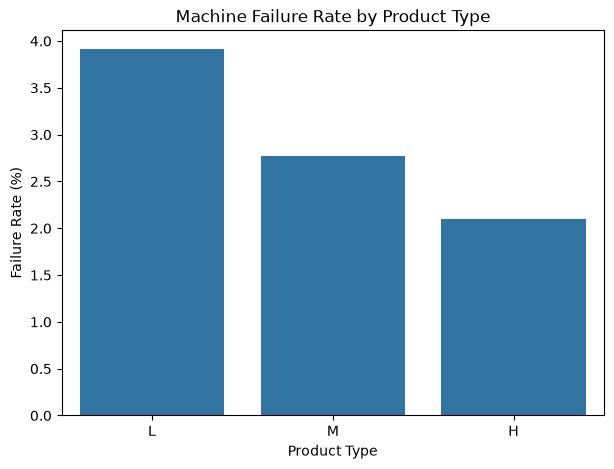

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_failure_rate_percentage.index,
    y=type_failure_rate_percentage.values
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")

plt.show()

In [20]:
correlation_matrix = data[numerical_features + ["Machine failure"]].corr()

correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


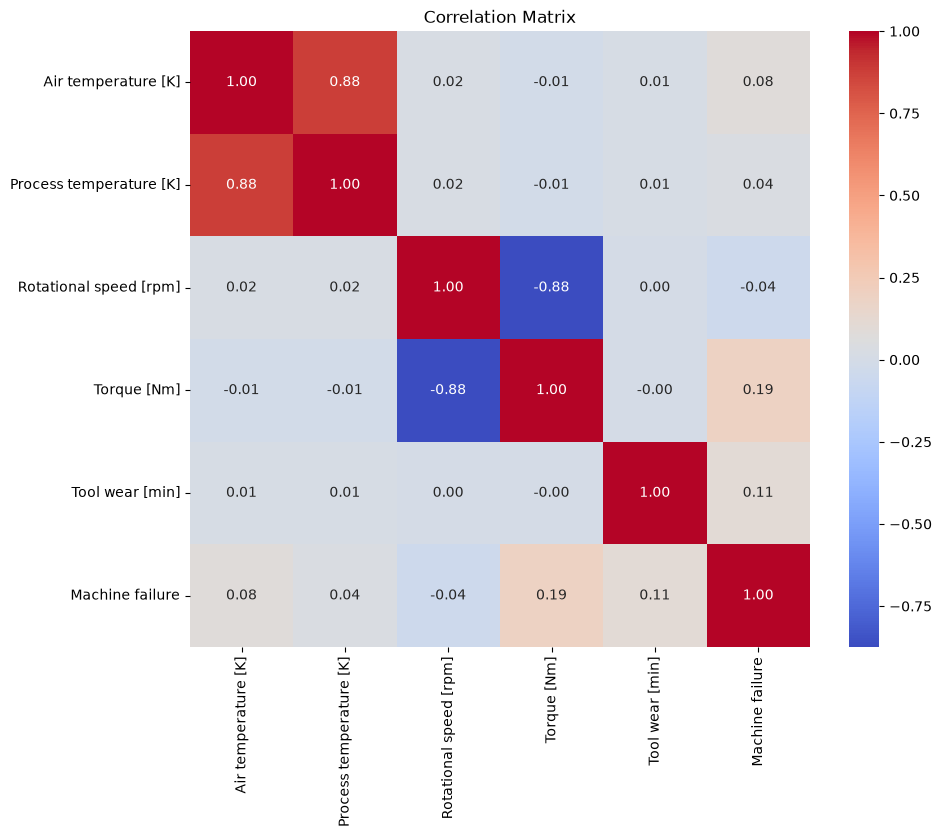

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
failure_correlations = (
    correlation_matrix["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

print(failure_correlations)

Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Machine failure, dtype: float64


In [52]:
data["Tool wear group"] = pd.cut(
    data["Tool wear [min]"],
    bins=[-1, 50, 100, 150, 200, 250, 300],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "201-250",
        "251-300"
    ]
)

In [53]:
tool_wear_analysis = data.groupby(
    "Tool wear group",
    observed=True
)["Machine failure"].agg(
    Total_Observations="count",
    Failures="sum",
    Failure_Rate="mean"
)

tool_wear_analysis["Failure_Rate"] *= 100

tool_wear_analysis

,Total_Observations,Failures,Failure_Rate
Tool wear group,,,
0-50,2396,52,2.170284
51-100,2271,53,2.333774
101-150,2295,50,2.178649
151-200,2276,66,2.899824
201-250,760,116,15.263158
251-300,2,2,100.000000


In [29]:
tool_wear_failure_rate = (
    data.groupby("Tool wear group", observed=True)["Machine failure"]
    .mean() * 100
)

print(tool_wear_failure_rate)

Tool wear group
0-50         2.170284
51-100       2.333774
101-150      2.178649
151-200      2.899824
201-250     15.263158
251-300    100.000000
Name: Machine failure, dtype: float64


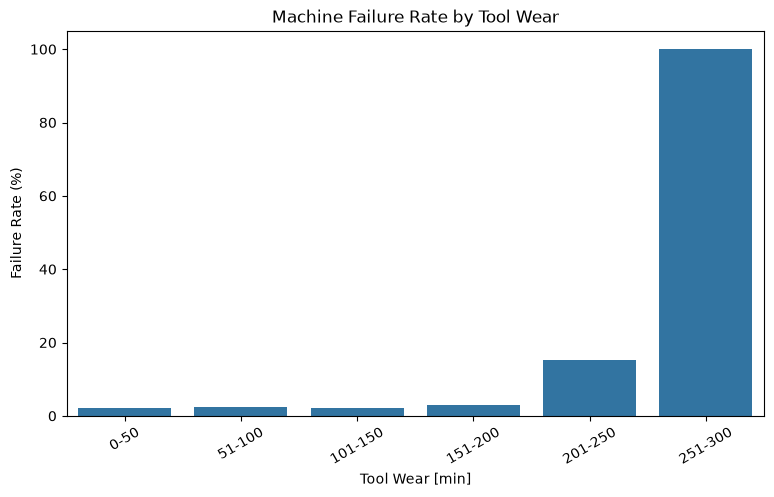

In [54]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tool_wear_analysis.index,
    y=tool_wear_analysis["Failure_Rate"]
)

plt.title("Machine Failure Rate by Tool Wear")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [56]:
data["Torque group"] = pd.cut(
    data["Torque [Nm]"],
    bins=5
)

In [57]:
print(data["Torque group"].value_counts().sort_index())

Torque group
(3.727, 18.36]     150
(18.36, 32.92]    2280
(32.92, 47.48]    5294
(47.48, 62.04]    2145
(62.04, 76.6]      131
Name: count, dtype: int64


In [58]:
torque_analysis = data.groupby(
    "Torque group",
    observed=True
)["Machine failure"].agg(
    Total_Observations="count",
    Failures="sum",
    Failure_Rate="mean"
)

torque_analysis["Failure_Rate"] *= 100

torque_analysis

,Total_Observations,Failures,Failure_Rate
Torque group,,,
"(3.727, 18.36]",150,32,21.333333
"(18.36, 32.92]",2280,15,0.657895
"(32.92, 47.48]",5294,51,0.963355
"(47.48, 62.04]",2145,166,7.738928
"(62.04, 76.6]",131,75,57.251908


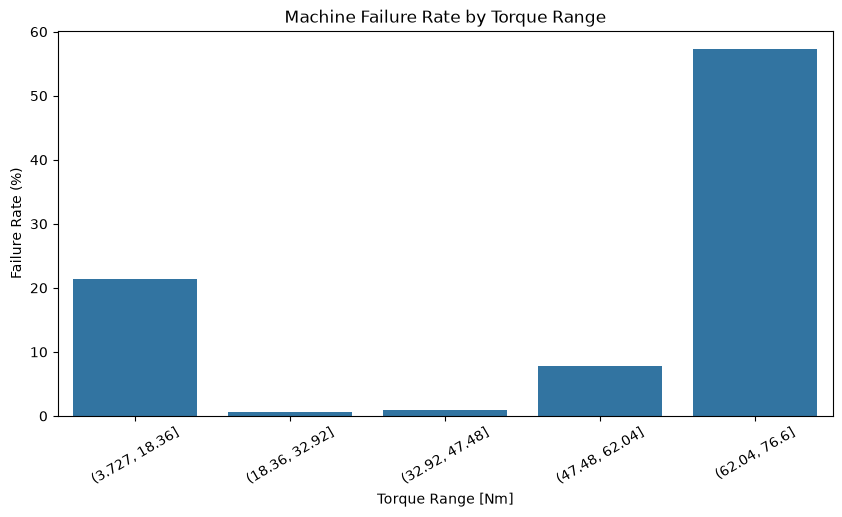

In [59]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=torque_analysis.index.astype(str),
    y=torque_analysis["Failure_Rate"]
)

plt.title("Machine Failure Rate by Torque Range")
plt.xlabel("Torque Range [Nm]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [60]:
data["Speed group"] = pd.cut(
    data["Rotational speed [rpm]"],
    bins=5
)

In [61]:
print(data["Speed group"].value_counts().sort_index())

Speed group
(1166.282, 1511.6]    5252
(1511.6, 1855.2]      4214
(1855.2, 2198.8]       438
(2198.8, 2542.4]        66
(2542.4, 2886.0]        30
Name: count, dtype: int64


In [62]:
speed_analysis = data.groupby(
    "Speed group",
    observed=True
)["Machine failure"].agg(
    Total_Observations="count",
    Failures="sum",
    Failure_Rate="mean"
)

speed_analysis["Failure_Rate"] *= 100

speed_analysis

,Total_Observations,Failures,Failure_Rate
Speed group,,,
"(1166.282, 1511.6]",5252,281,5.350343
"(1511.6, 1855.2]",4214,21,0.498339
"(1855.2, 2198.8]",438,6,1.369863
"(2198.8, 2542.4]",66,5,7.575758
"(2542.4, 2886.0]",30,26,86.666667


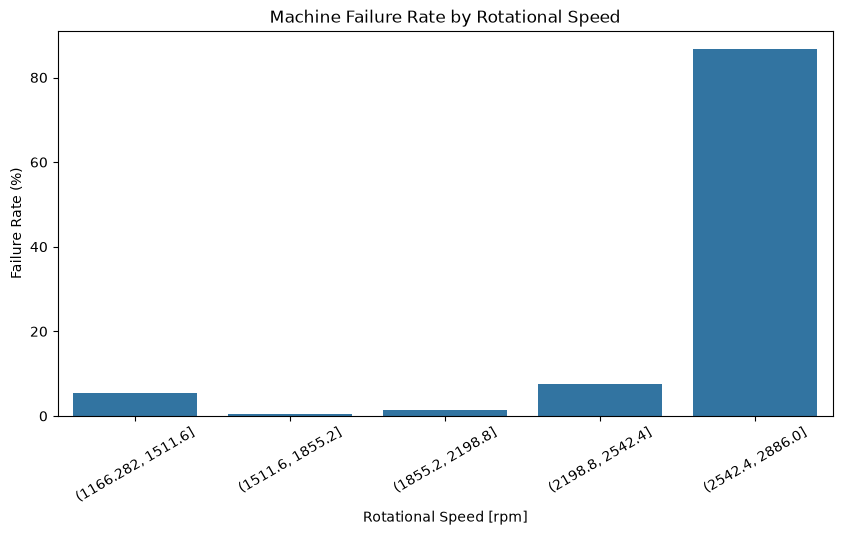

In [63]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=speed_analysis.index.astype(str),
    y=speed_analysis["Failure_Rate"]
)

plt.title("Machine Failure Rate by Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [64]:
data["Temperature difference [K]"] = (
    data["Process temperature [K]"]
    - data["Air temperature [K]"]
)

In [65]:
data["Temperature difference [K]"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature difference [K], dtype: float64

In [66]:
temperature_difference_analysis = (
    data.groupby("Machine failure")[
        "Temperature difference [K]"
    ].agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
)

temperature_difference_analysis

,Mean,Median,Minimum,Maximum
Machine failure,,,,
0,10.021571,9.8,7.6,12.1
1,9.403835,9.3,7.6,12.0


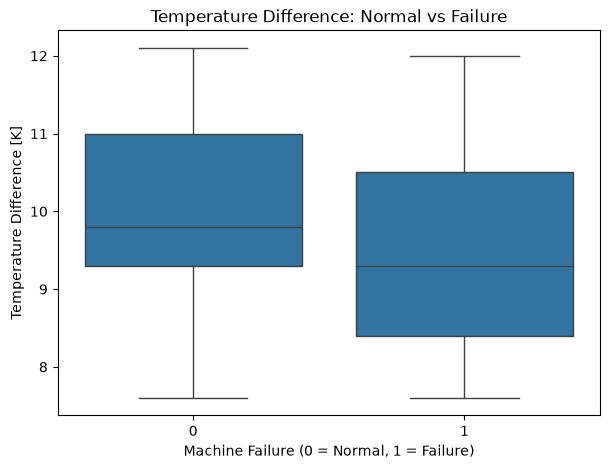

In [67]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="Machine failure",
    y="Temperature difference [K]"
)

plt.title("Temperature Difference: Normal vs Failure")
plt.xlabel("Machine Failure (0 = Normal, 1 = Failure)")
plt.ylabel("Temperature Difference [K]")

plt.show()

In [68]:
data["Temperature difference group"] = pd.cut(
    data["Temperature difference [K]"],
    bins=5
)

In [69]:
temperature_analysis = data.groupby(
    "Temperature difference group",
    observed=True
)["Machine failure"].agg(
    Total_Observations="count",
    Failures="sum",
    Failure_Rate="mean"
)

temperature_analysis["Failure_Rate"] *= 100

temperature_analysis

,Total_Observations,Failures,Failure_Rate
Temperature difference group,,,
"(7.595, 8.5]",562,94,16.725979
"(8.5, 9.4]",2680,93,3.470149
"(9.4, 10.3]",2646,58,2.191988
"(10.3, 11.2]",2817,69,2.449414
"(11.2, 12.1]",1295,25,1.930502


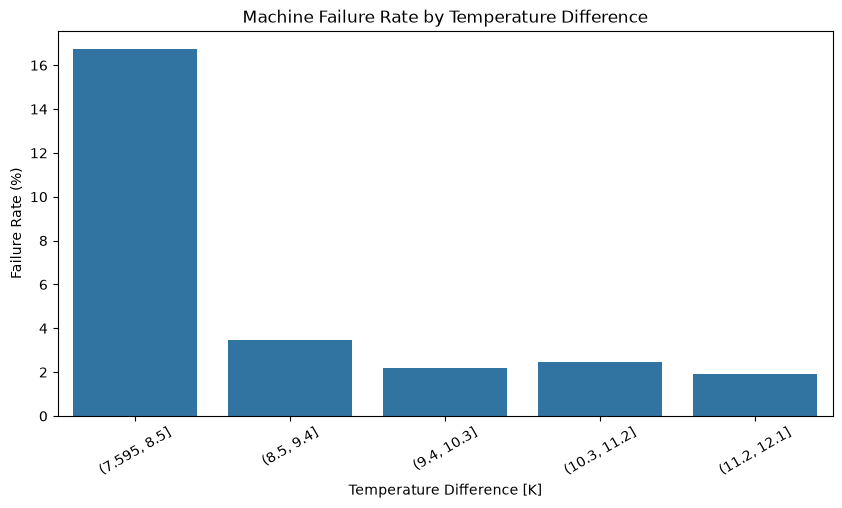

In [70]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=temperature_analysis.index.astype(str),
    y=temperature_analysis["Failure_Rate"]
)

plt.title("Machine Failure Rate by Temperature Difference")
plt.xlabel("Temperature Difference [K]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [71]:
eda_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Normal Mean": [
        data[data["Machine failure"] == 0][feature].mean()
        for feature in numerical_features
    ],
    "Failure Mean": [
        data[data["Machine failure"] == 1][feature].mean()
        for feature in numerical_features
    ]
})

eda_summary["Difference"] = (
    eda_summary["Failure Mean"]
    - eda_summary["Normal Mean"]
)

eda_summary

,Feature,Normal Mean,Failure Mean,Difference
0,Air temperature [K],299.973999,300.886431,0.912432
1,Process temperature [K],309.995570,310.290265,0.294696
2,Rotational speed [rpm],1540.260014,1496.486726,-43.773289
3,Torque [Nm],39.629655,50.168142,10.538486
4,Tool wear [min],106.693717,143.781711,37.087994


In [72]:
failure_correlations = (
    correlation_matrix["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

correlation_summary = failure_correlations.reset_index()

correlation_summary.columns = [
    "Feature",
    "Correlation with Machine Failure"
]

correlation_summary

,Feature,Correlation with Machine Failure
0,Torque [Nm],0.191321
1,Tool wear [min],0.105448
2,Air temperature [K],0.082556
3,Rotational speed [rpm],-0.044188
4,Process temperature [K],0.035946


In [73]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [74]:
eda_only_columns = [
    "Tool wear group",
    "Torque group",
    "Speed group",
    "Temperature difference [K]",
    "Temperature difference group"
]

data = data.drop(columns=eda_only_columns)

In [75]:
print(data.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [76]:
print("=" * 50)
print("FINAL EDA CHECK")
print("=" * 50)

print("\nDataset shape:")
print(data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum().sum())

print("\nDuplicates:")
print(data.duplicated().sum())

print("\nMachine failure distribution:")
print(data["Machine failure"].value_counts())

print("\nFailure percentages:")
print(
    data["Machine failure"]
    .value_counts(normalize=True)
    .mul(100)
)

FINAL EDA CHECK

Dataset shape:
(10000, 7)

Columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

Missing values:
0

Duplicates:
0

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


## Final EDA Findings

### 1. Class Imbalance

The dataset contains 9,661 normal observations and 339 machine-failure observations. Therefore, only 3.39% of the observations represent machine failure. This significant class imbalance means that accuracy alone will not be sufficient for evaluating the final predictive model.

### 2. Torque

Failure observations show noticeably higher torque values than normal observations. The mean torque is approximately 50.17 Nm for failure observations compared with 39.63 Nm for normal observations. Torque also has the strongest linear correlation with machine failure among the numerical features, with a correlation of approximately 0.191.

### 3. Tool Wear

Failure observations generally show higher tool wear. The mean tool wear is approximately 143.78 minutes for failure observations compared with 106.69 minutes for normal observations. Tool wear has a positive correlation of approximately 0.105 with machine failure.

### 4. Rotational Speed

Failure observations generally have lower rotational speeds. The mean rotational speed is approximately 1496.49 rpm for failure observations compared with 1540.26 rpm for normal observations. The correlation with machine failure is weakly negative at approximately -0.044.

### 5. Temperature

Air temperature shows a small positive association with machine failure, while process temperature shows a very weak positive correlation. The box-plot analysis also shows substantial overlap between normal and failure observations, suggesting that temperature alone may not be sufficient to distinguish failures.

### 6. Product Type

Failure rates differ across product types. Type L has the highest observed failure rate at approximately 3.9%, followed by Type M at approximately 2.8% and Type H at approximately 2.1%. This suggests that product type may contain useful predictive information and will therefore be retained as a categorical feature.

### 7. Feature Relationships

Strong relationships were observed between some input variables. Air temperature and process temperature have a correlation of approximately 0.876, while rotational speed and torque have a correlation of approximately -0.875. These relationships indicate that some features contain overlapping information.

### 8. Nonlinear Relationships

The relatively low individual correlations with machine failure suggest that failure may not be explained by a single linear relationship. Therefore, machine learning models capable of capturing nonlinear relationships and feature interactions will be investigated.

### 9. Next Step

The EDA results will guide feature engineering and model development. Multiple machine learning algorithms will be trained and evaluated using appropriate metrics for the imbalanced failure-prediction problem.